# The density of states: smearing and tetrahedra

How many states per unit energy the crystal has. It is a Brillouin-zone integral of a delta
function, which is the one integral a finite k-grid is bad at, and two families answer it.
**Smearing** replaces the delta by something of finite width; **tetrahedra** interpolate the
bands linearly between k-points and integrate exactly. Both are here, both also work as
occupation schemes inside the self-consistent loop, and a run reports the scheme it used.

What is wanted is

$$D(E) = \sum_n \int_{\rm BZ} \frac{d\mathbf k}{(2\pi)^3}\,
        \delta(E - \varepsilon_{n\mathbf k}),$$

and what a smearing scheme writes down is its *integral*, the count of states below $E$,

$$N(E) = \sum_{n\mathbf k} w_{\mathbf k}\,
       f\!\left(\frac{E - \varepsilon_{n\mathbf k}}{\sigma}\right),
\qquad D(E) = \frac{dN}{dE}.$$

| | here | |
|---|---|---|
| silicon's gap, on a $12^3$ grid | **0.479 eV** | 1.17 eV, measured |
| $D(E)$ at mid-gap, tetrahedra | **0.00** | zero, exactly |
| $D(E)$ at mid-gap, Gaussian $\sigma = 0.02$ Ry | **0.027 states/eV** | a floor that is not there |
| aluminium's total energy | **-4.16607791 Ry** | 2.5e-08 from `pw.x` |
| aluminium's states below $E_F$ | **3.000003** | 3, the valence count |

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

from defumat import Calculator
from defumat.io import read_qe_output
from defumat.units import RY_TO_EV

QE = Path("../quantum_espresso/qe-7.5-ReleasePack/qe-7.5/test-suite")
PSEUDO = Path("../tests/data/pseudo")

silicon = Calculator.from_file(QE / "pw_scf" / "scf.in", pseudo_dir=PSEUDO,
                               announce=False, conv_thr=1e-10)
tetra = silicon.get_dos(grid=(12, 12, 12), nbnd=8, scheme="tetrahedra")

A density of states is a **non-self-consistent** run on top of a converged one: the density
is fixed on the coarse grid the self-consistent loop used, and the bands are diagonalised
once on a much denser grid at that fixed potential. Nothing is self-consistent about the
second step, which is why it can afford ten times the k-points.

## Silicon: the gap is what separates the two schemes

Inside a gap the true density of states is exactly zero. Tetrahedra reproduce that
*exactly* -- the interpolation puts no band there, so no tetrahedron contributes -- while a
Gaussian of width 0.02 Ry smears occupied states across the gap edge and leaves a floor of
0.027 states/eV that has no physical counterpart at all. For a **metal** the ordering is reversed, since smearing is what makes a
partially filled band integrable on a finite grid at all -- which is why both families exist
and neither is a default for everything.

indirect gap        0.4790 eV   (measured 1.17)
D at mid-gap        tetrahedra 0.00e+00,  Gaussian 2.73e-02 states/eV
states counted      15.9999999995   (8 bands, two electrons each)


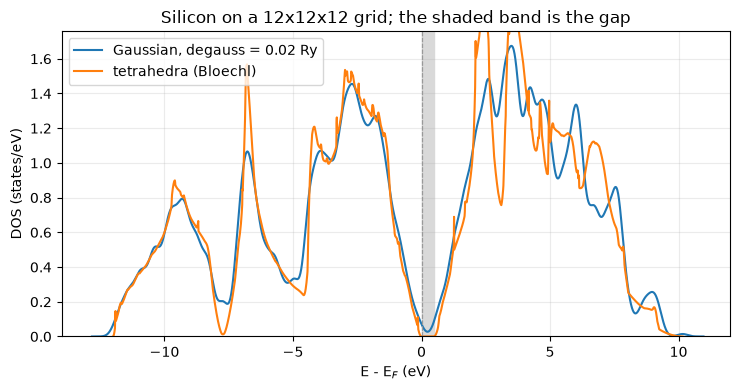

In [2]:
gauss = silicon.get_dos(grid=(12, 12, 12), nbnd=8, scheme="gaussian", degauss=0.02)
levels = np.asarray(silicon.dos_states.eigenvalues)
top, bottom = levels[:, 3].max(), levels[:, 4].min()

fig, ax = plt.subplots(figsize=(7.5, 4.0))
gauss.plot(ax=ax, label="Gaussian, degauss = 0.02 Ry")
tetra.plot(ax=ax, label="tetrahedra (Bloechl)")
zero = tetra.fermi_energy          # `plot` puts the Fermi level (here the HOMO) at 0
ax.axvspan((top - zero) * RY_TO_EV, (bottom - zero) * RY_TO_EV, color="0.85", zorder=0)
ax.set_xlim(-14.0, 12.0)
ax.set_title("Silicon on a 12x12x12 grid; the shaded band is the gap")
ax.legend()
ax.grid(alpha=0.25)
fig.tight_layout()

middle = 0.5 * (top + bottom)
print("indirect gap        %.4f eV   (measured 1.17)" % ((bottom - top) * RY_TO_EV))
print("D at mid-gap        tetrahedra %.2e,  Gaussian %.2e states/eV"
      % (tetra.at(middle) / RY_TO_EV, gauss.at(middle) / RY_TO_EV))
print("states counted      %.10f   (8 bands, two electrons each)"
      % tetra.total_integrated[-1])

## The smeared delta is the derivative of the occupation function

Only $N(E)$ is written down here and $D(E)$ is its derivative, which is not a trick but the
definition: a smearing scheme is a *choice of occupation function*, and the smeared delta is
that function differentiated. The four families differ only in which one they choose, and
each integrates to exactly 1 however oddly shaped -- Methfessel-Paxton and the cold smearing
both go negative, which is what lets them cancel the leading error of the Gaussian.

Gaussian                     integral = 1.0000000000
Methfessel-Paxton            integral = 1.0000000000
cold (Marzari-Vanderbilt)    integral = 1.0000000000
Fermi-Dirac                  integral = 1.0000000000


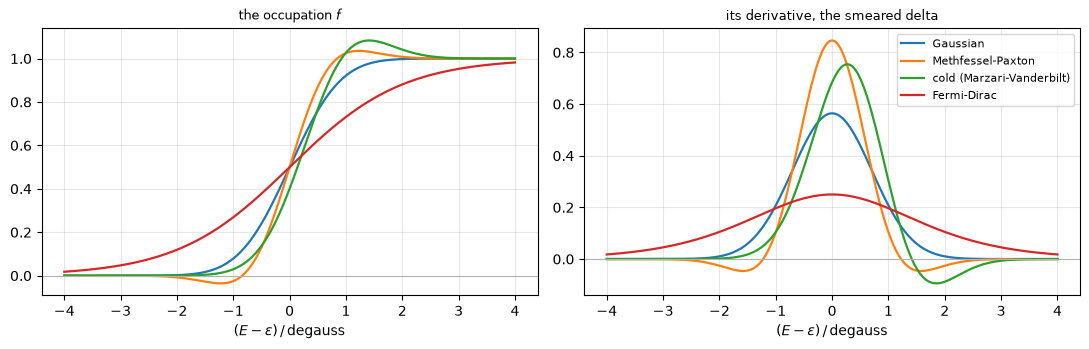

In [3]:
from defumat.scf.occupations import w0gauss, wgauss   # no facade route to one scheme

x = np.linspace(-4.0, 4.0, 801)
NAMES = {0: "Gaussian", 1: "Methfessel-Paxton", -1: "cold (Marzari-Vanderbilt)",
         -99: "Fermi-Dirac"}

fig, axes = plt.subplots(1, 2, figsize=(11.0, 3.6))
for ngauss, label in NAMES.items():
    axes[0].plot(x, wgauss(x, ngauss), lw=1.6, label=label)
    axes[1].plot(x, w0gauss(x, ngauss), lw=1.6, label=label)
axes[0].set_title("the occupation $f$", fontsize=9)
axes[1].set_title("its derivative, the smeared delta", fontsize=9)
for ax in axes:
    ax.set_xlabel(r"$(E - \varepsilon)\,/\,$degauss")
    ax.axhline(0.0, color="0.7", lw=0.8)
    ax.grid(alpha=0.3)
axes[1].legend(fontsize=8)
fig.tight_layout()

wide = np.linspace(-40.0, 40.0, 400001)
for ngauss, label in NAMES.items():
    print("%-28s integral = %.10f"
          % (label, np.trapezoid(np.asarray(w0gauss(wide, ngauss)), wide)))

## Aluminium, against Quantum ESPRESSO

In a metal the scheme decides the *answer* and not merely the picture, because the
occupations themselves depend on it and so does the total energy. This is QE's own
tetrahedron benchmark, and the self-consistent run uses the scheme its input asks for.

In [4]:
aluminium = Calculator.from_file(QE / "pw_metal" / "metal-tetrahedra.in",
                                 pseudo_dir=PSEUDO, announce=False, conv_thr=1e-10)
scf = aluminium.get_scf()
theirs = read_qe_output(QE / "pw_metal" / "benchmark.out.git.inp=metal-tetrahedra.in")

print("occupations = %r,  %d irreducible k-points"
      % (aluminium.system.occupations, aluminium.system.kpoints.nk))
print("total energy   %.8f Ry   pw.x %.8f   difference %.1e"
      % (scf.total_energy, theirs.total_energy, scf.total_energy - theirs.total_energy))
print("Fermi energy   %.4f eV     pw.x %.4f     difference %.1e"
      % (scf.fermi_energy * RY_TO_EV, theirs.fermi_energy,
         scf.fermi_energy * RY_TO_EV - theirs.fermi_energy))

occupations = 'tetrahedra-opt',  10 irreducible k-points
total energy   -4.16607791 Ry   pw.x -4.16607788   difference -2.5e-08
Fermi energy   8.1535 eV     pw.x 8.1533     difference 2.4e-04


And the picture that says aluminium is the textbook free-electron metal: $D(E)$ following
$\sqrt{E - E_0}$ almost all the way to $E_F$, and the states counted below the Fermi level
coming back as three electrons.

states below E_F   3.000003   (3 valence electrons)
D(E_F)             0.3751 states/eV/cell


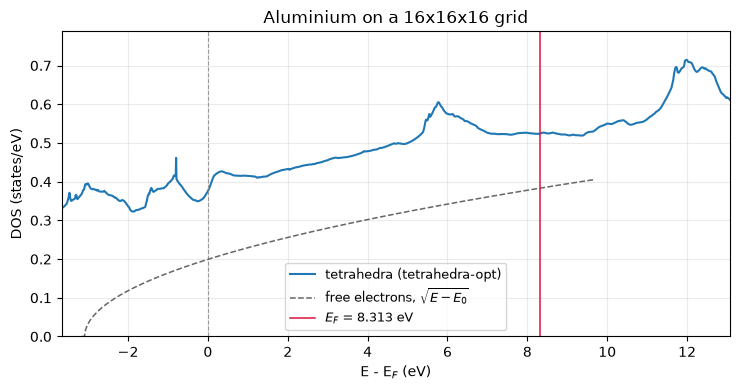

In [5]:
dos = aluminium.get_dos(grid=(16, 16, 16), nbnd=6)
fermi, floor = dos.fermi_energy, np.asarray(aluminium.dos_states.eigenvalues).min()

window = (dos.energies > floor + 0.03) & (dos.energies < floor + 0.30)
slope, intercept = np.polyfit(dos.energies[window], dos.dos[window] ** 2, 1)
free = np.sqrt(np.maximum(slope * dos.energies + intercept, 0.0))
shown = dos.energies < fermi + 0.1

fig, ax = plt.subplots(figsize=(7.5, 4.0))
dos.plot(ax=ax, label="tetrahedra (%s)" % dos.scheme)
ax.plot(dos.energies_ev[shown], (free / RY_TO_EV)[shown], "--", lw=1.1, color="0.4",
        label=r"free electrons, $\sqrt{E - E_0}$")
ax.axvline(fermi * RY_TO_EV, color="crimson", lw=1.1,
           label=r"$E_F$ = %.3f eV" % (fermi * RY_TO_EV))
ax.set_xlim(floor * RY_TO_EV - 0.5, (fermi + 0.35) * RY_TO_EV)
ax.set_title("Aluminium on a 16x16x16 grid")
ax.legend(fontsize=9)
ax.grid(alpha=0.25)
fig.tight_layout()

print("states below E_F   %.6f   (3 valence electrons)" % dos.states_below(fermi))
print("D(E_F)             %.4f states/eV/cell" % (dos.at(fermi) / RY_TO_EV))

$D(E_F)$ is the number the electronic specific heat and the superconducting coupling constant
are both built out of, which is most of what a metal's density of states is wanted for.

The spin-resolved version of this plot -- nickel's two channels with the moment read off the
integrated curves -- is in notebook 07.

---
The tests behind this notebook: `tests/regression/test_dos.py`, which holds the integrated
count returning the electron number on every scheme, the empty gap, the free-electron fit,
and the agreement of the schemes on where $E_F$ is; `tests/regression/test_tetrahedra.py`,
which holds QE's three tetrahedron variants -- linear, Bloechl-corrected and optimised --
against their own benchmarks, including the check that the three genuinely disagree by more
than the tolerance they are compared at; and `tests/unit/test_bz_integration.py`.